In [1]:
import sys, os
sys.path.insert(0, os.path.expanduser('~'))
import mpl_theme; mpl_theme.apply();

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6
plt.rcParams['xtick.major.pad'] = 1.5
plt.rcParams['ytick.major.pad'] = 1.5
plt.rcParams['xtick.major.width'] = 0.25
plt.rcParams['ytick.major.width'] = 0.25
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['axes.linewidth'] = 0.25
plt.rcParams['lines.linewidth'] = 0.5
plt.rcParams['axes.labelpad'] = 2
plt.rcParams['svg.fonttype'] = 'none'

%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd

import pickle
import glob

from utils import *
from analysis_utils import *

from tqdm import tqdm

figures_path = 'bild_outputs/figures'


[mpl_theme] applied 'CMU Sans Serif' with custom color cycle.


/mnt/md0/jjusuf/miniconda3/envs/bild2/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load inference data

In [2]:
conditions = ['340kb_Ce_Cp_None', '340kb_None', '340kb_Ce_Cp_IAA']
colors_dict = {'340kb_Ce_Cp_None': 'C0',
               '340kb_Ce_Cp_IAA': 'C4',
               '340kb_None': 'C3'}
names_dict = {'340kb_Ce_Cp_None': 'untreated',
              '340kb_Ce_Cp_IAA': '∆RAD21',
              '340kb_None': '∆CTCFsites'}

final_inferences_all = {}
track_names_all = {}

for condition in conditions:
    save_folder = f'/mnt/md0/jjusuf/bild/synEP_bild/bild_outputs/bild_profiles/{condition}_initial_dE_2.0'

    filenames = [os.path.basename(fn) for fn in glob.glob(os.path.join(save_folder,'*'))]

    profile_info = []
    for fn in filenames:
        track_name, suffix = fn.split('_bild_result_frame_')
        frames_str = suffix[:-4]
        start_frame, end_frame = frames_str.split('_to_')
        start_frame = int(start_frame)
        end_frame = int(end_frame)
        profile_info.append({'track_name': track_name,
                            'start_frame': start_frame,
                            'end_frame': end_frame,
                            'filename': fn})
        
    profile_info = pd.DataFrame(profile_info)
    profile_info = profile_info.sort_values(['track_name', 'start_frame'])
    profile_info.index = np.arange(len(profile_info))

    track_names = np.unique(profile_info['track_name'])

    max_unchopped_traj_len = np.max(profile_info['end_frame'])

    # make matrix to store inferences; store multiple inferences along 3rd dimension
    inferences = np.zeros((len(track_names), max_unchopped_traj_len, 2), dtype='int8') * np.nan
    dist_from_end = np.zeros(inferences.shape, dtype='int') * np.nan

    dE = 2
    for track_name_idx in range(len(track_names)):
        track_name = track_names[track_name_idx]
        profiles_this_track = profile_info.loc[profile_info['track_name']==track_name]
        for i in range(len(profiles_this_track)):
            track_name, start_frame, end_frame, fn = profiles_this_track.iloc[i]
            bild_result = pickle.load(open(os.path.join(save_folder, fn), 'rb'))
            best_profile = bild_result.best_profile(dE=dE)
            best_profile = np.array(list(best_profile)).astype('int8')
            best_profile = pd.Series(best_profile, index=np.arange(start_frame, end_frame))
            for frame_num in range(start_frame, end_frame):
                k = 0
                while not np.isnan(inferences[track_name_idx, frame_num, k]):
                    k += 1
                    if k > inferences.shape[2]:
                        raise RuntimeError('3rd dimension of inferences not large enough!')
                inferences[track_name_idx, frame_num, k] = best_profile[frame_num]
                dist_from_end[track_name_idx, frame_num, k] = min(frame_num-start_frame, end_frame-frame_num)

    final_inferences = np.zeros((inferences.shape[0], inferences.shape[1])) * np.nan
    for track_name_idx in range(len(track_names)):
        for frame_num in range(max_unchopped_traj_len):
            inf1 = inferences[track_name_idx, frame_num, 0]
            inf2 = inferences[track_name_idx, frame_num, 1]
            if np.isnan(inf1) and np.isnan(inf2):
                inf = np.nan
            elif np.isnan(inf2):
                inf = inf1
            elif inf1 != inf2:
                if dist_from_end[track_name_idx, frame_num, 0] > dist_from_end[track_name_idx, frame_num, 1]:
                    inf = inf1
                else:
                    inf = inf2
            else:
                inf = inf1  # doesn't matter, they will be the same
            final_inferences[track_name_idx, frame_num] = inf

    track_names_all[condition] = track_names
    final_inferences_all[condition] = final_inferences.copy()


## Panel c: Show examples

In [3]:
def plot_track_with_profile(condition, i, ymin=None, ymax=None):

    original_trajs_nl, downsampled_trajs_nl = get_original_downsampled_trajs(condition, min_traj_len=100, print_output=False)
    data_list_original = [np.array(traj) for traj in original_trajs_nl]
    data_list_downsampled = [np.array(traj) for traj in downsampled_trajs_nl]

    names_parts = track_names_all[condition][i].split('_')
    track_type = names_parts[0]  # original or downsampled
    track_num = int(names_parts[2])
    if track_type == 'original':
        traj = data_list_original[track_num]
    elif track_type == 'downsampled':
        traj = data_list_downsampled[track_num]
    else:
        raise ValueError('track_type must be "original" or "downsampled"')

    dist_3d = np.sqrt(np.sum(np.square(traj), 1))
    profile = final_inferences_all[condition][i,:]
    profile = profile[:np.where(~np.isnan(profile))[0][-1] + 1]  # remove trailing NaNs
    dist_3d = dist_3d[:len(profile)]  # truncate

    t_minutes = np.arange(len(dist_3d)) * 30/60
    extent_L = t_minutes[0]-0.25
    extent_R = t_minutes[-1]+0.25

    cmap = LinearSegmentedColormap.from_list("white_purple", ["white", "#571e51"])

    fig, axs = plt.subplots(2, 1, gridspec_kw={'height_ratios': [5, 1], 'hspace': 0}, figsize=(1.4,1.2), dpi=300, frameon=False)
    axs[0].plot(t_minutes, dist_3d*1000, color=colors_dict[condition])
    axs[0].set_xlim(t_minutes[0], t_minutes[-1])
    axs[0].set_ylabel('3D distance [nm]');
    axs[0].set_xticks([])
    axs[0].set_ylim(ymin, ymax)
    axs[0].spines[['bottom', 'top', 'right']].set_visible(False)
    axs[1].imshow(profile.reshape((1, len(profile))), aspect=len(profile)/25, extent=[extent_L, extent_R, 0, 1], cmap=cmap)
    axs[1].set_xlim(t_minutes[0], t_minutes[-1])
    axs[1].set_yticks([]);
    axs[1].set_xlabel('Time [min]');
    


In [4]:
# # to print which profiles satisfy certain length criteria
# for i in range(len(final_inferences_all['340kb_Ce_Cp_IAA'])):
#     profile = final_inferences_all['340kb_Ce_Cp_IAA'][i,:]
#     profile = profile[:np.where(~np.isnan(profile))[0][-1] + 1]  # remove trailing NaNs
#     if np.abs(len(profile)-700)<50:
#         print(i, len(profile))

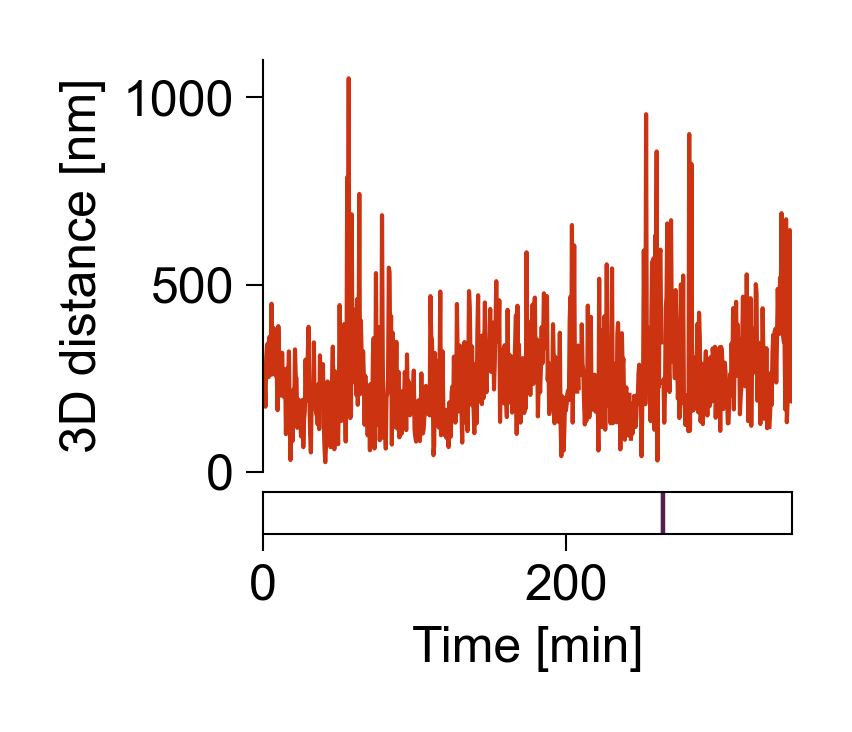

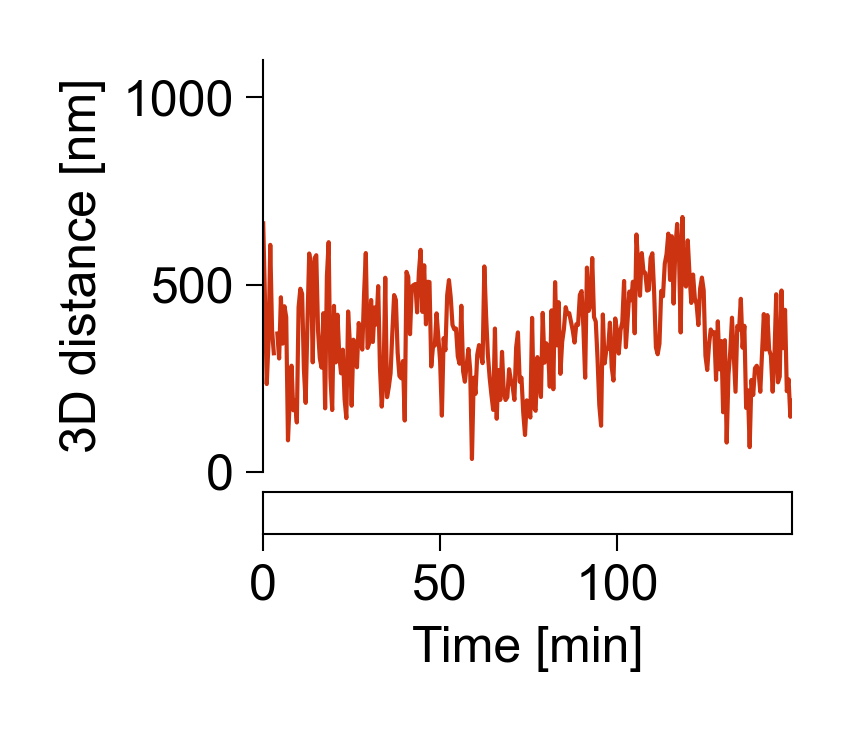

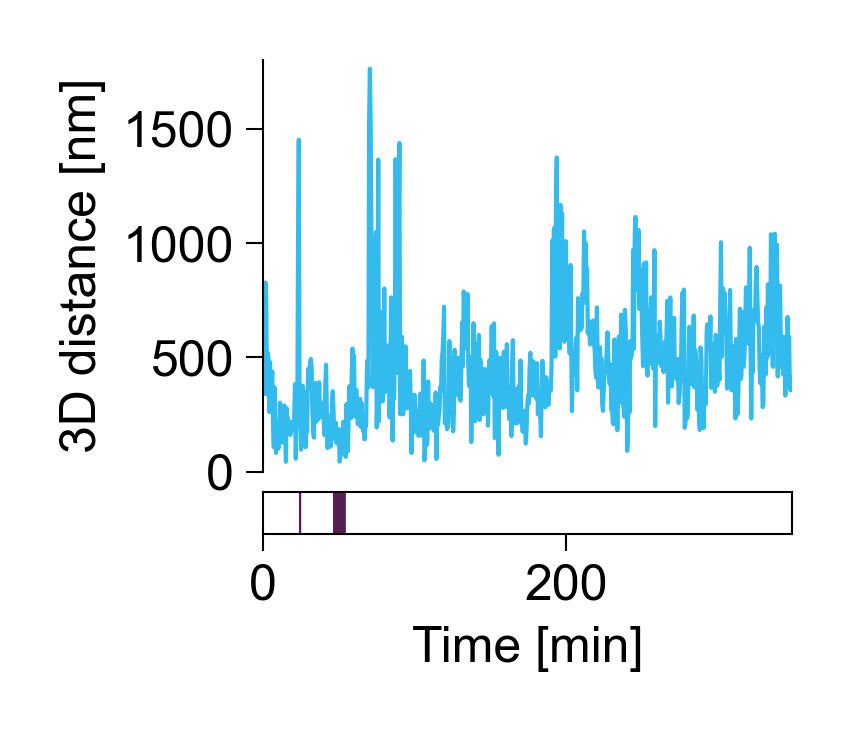

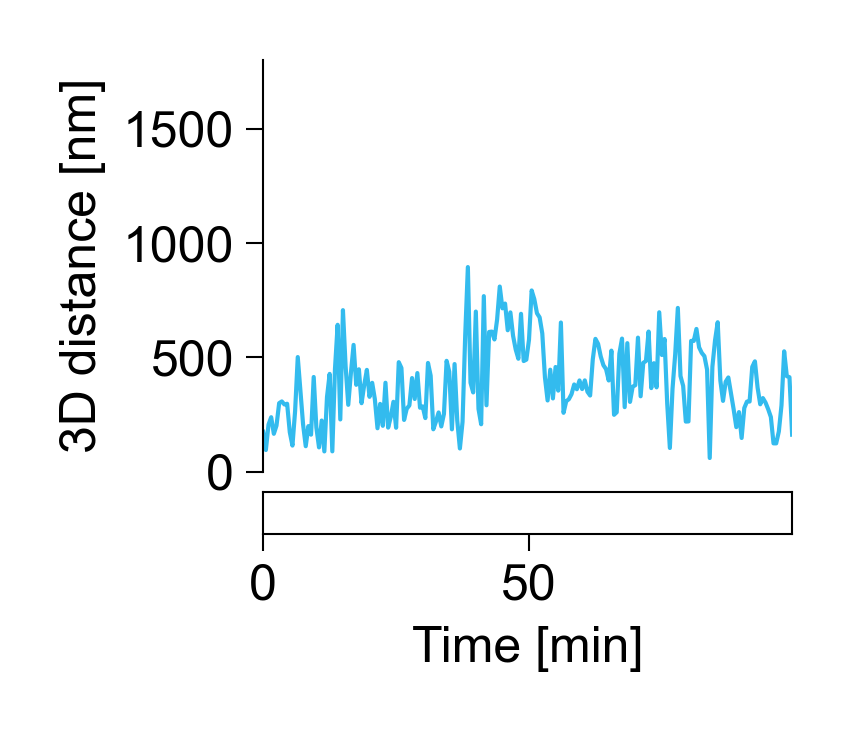

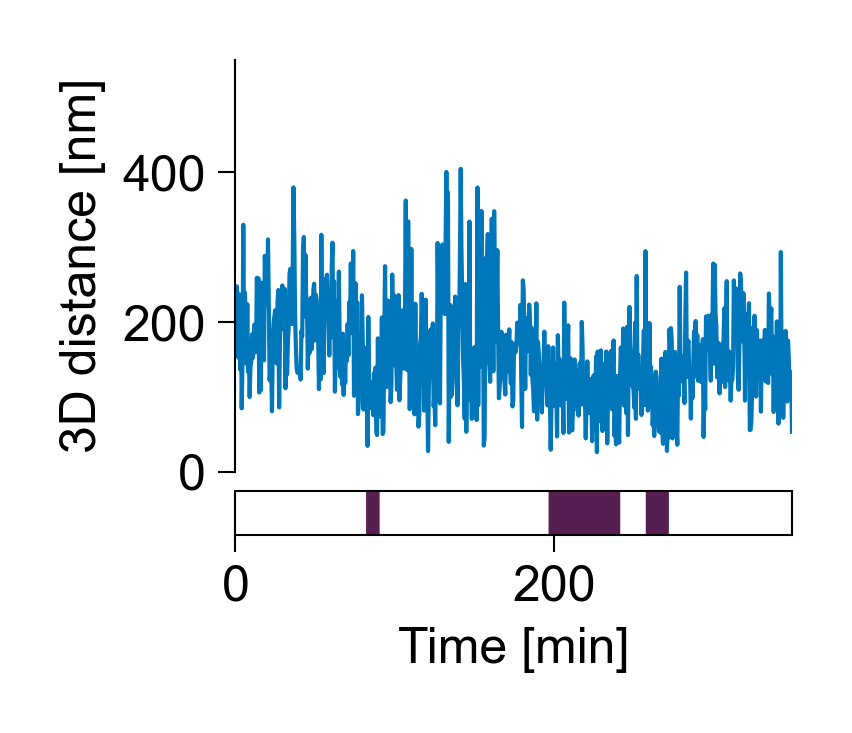

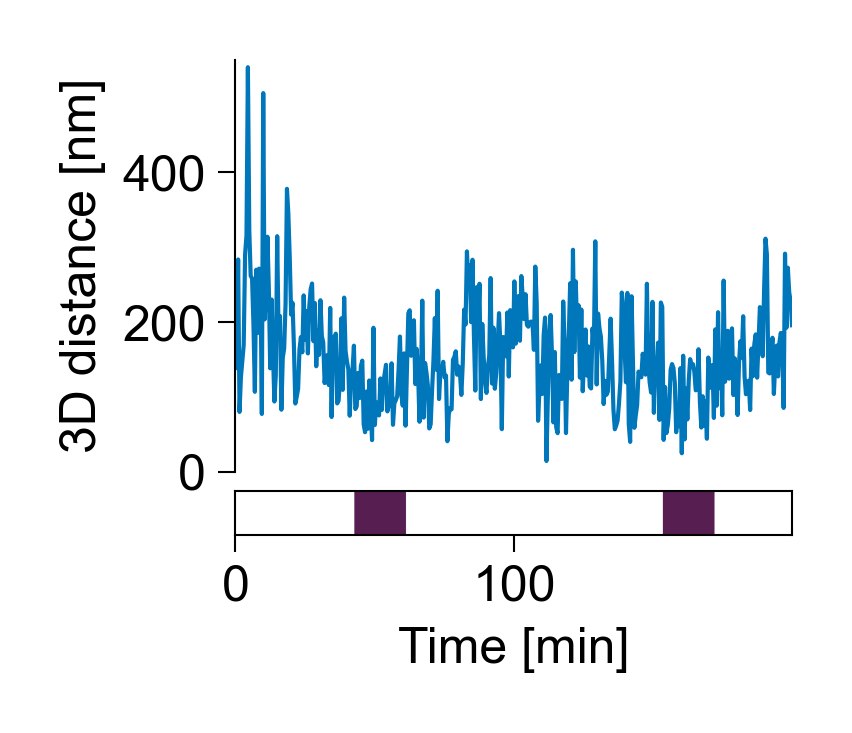

In [5]:
condition_names_to_plot = ['340kb_None', '340kb_None', '340kb_Ce_Cp_IAA', '340kb_Ce_Cp_IAA', '340kb_Ce_Cp_None', '340kb_Ce_Cp_None']
indices_to_plot = [69, 63, 69, 52, 106, 112]
ymax_arr = [1100, 1100, 1800, 1800, 550, 550]

for condition, index, ymax in zip(condition_names_to_plot, indices_to_plot, ymax_arr):
    plot_track_with_profile(condition, index, ymin=0, ymax=ymax)
    plt.tight_layout()
    plt.savefig(f'{figures_path}/example_traj_and_profile_{condition}_{index}.svg')

# Get looped fractions and lifetimes

In [6]:
def false_positive_correct(arr_inferred):
    '''Apply false positive correction to an array of BILD looping fraction estimates (%),
    as in  Fig. S11G of Gabriele et al. 2022, for ΔE=2: f_inferred = 1.34*f_true + 2.3.'''
    arr_true = (arr_inferred - 2.3)/1.34
    return arr_true

In [7]:
corrected_looped_frac_bootstrap_dists = {}

for condition in conditions:
    final_inferences = final_inferences_all[condition]

    # Algorithm 4 in Fbn2 SI
    num_trajs = len(final_inferences)
    bootstrap_dist = []

    for bootstrap_repeat in tqdm(range(1000)):
        looped_frames = 0
        total_frames = 0
        for repeat in range(num_trajs):
            i = np.random.choice(np.arange(num_trajs))
            profile = final_inferences[i,:]
            profile = profile[~np.isnan(profile)]
            looped_frames += np.sum(profile==1)
            total_frames += np.sum(np.logical_or(profile==0,profile==1))
        percent_loop = looped_frames / total_frames * 100
        bootstrap_dist.append(percent_loop)

    bootstrap_dist = np.array(bootstrap_dist)
    bootstrap_dist = false_positive_correct(bootstrap_dist)

    corrected_looped_frac_bootstrap_dists[condition] = bootstrap_dist

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:01<00:00, 886.99it/s]


In [8]:
km_curves_with_CIs = {}
loop_lifetimes_medians_and_CIs = {}

for condition in conditions:
    final_inferences = final_inferences_all[condition]
    
    m, x, y, y_CI_lower, y_CI_upper = km_median_lifetime(final_inferences, return_ci=True)
    x = x*30/60  # convert to minutes

    m, m_std, m_ci, _ = km_median_bootstrap(final_inferences, n_boot=10, seed=0)
    m *= 30/60
    m_std *= 30/60  # don't need this for plots
    m_ci = (m_ci[0]*30/60, m_ci[1]*30/60)

    km_curves_with_CIs[condition] = (x, y, y_CI_lower, y_CI_upper)
    loop_lifetimes_medians_and_CIs[condition] = (m, m_ci)


# Panel d: Rescaled Kaplan-Meier curves

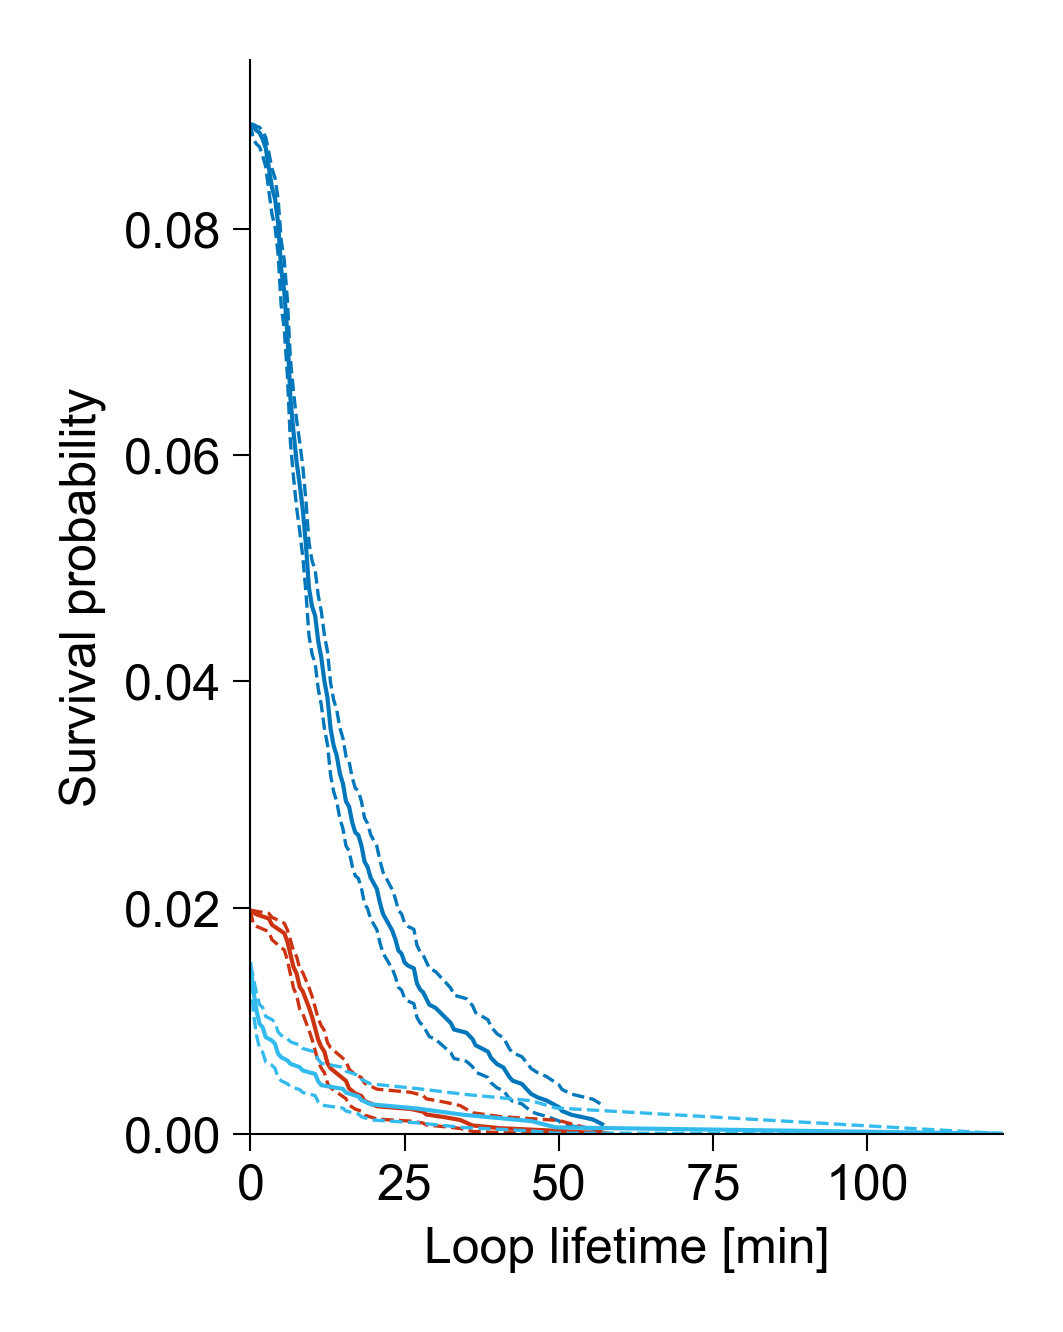

In [14]:
fig, ax = plt.subplots(figsize=(1.75, 2.2), dpi=300, frameon=False)

for condition in conditions:
    looped_frac = np.mean(corrected_looped_frac_bootstrap_dists[condition])
    x, y, y_CI_lower, y_CI_upper = km_curves_with_CIs[condition]

    # rescale by looped fraction
    y_rescaled = y * looped_frac/100
    y_CI_lower_rescaled = y_CI_lower * looped_frac/100
    y_CI_upper_rescaled = y_CI_upper * looped_frac/100

    ax.plot(x, y_rescaled, color=colors_dict[condition], linewidth=0.5)
    ax.plot(x, y_CI_lower_rescaled, color=colors_dict[condition], linestyle='--', linewidth=0.4)
    ax.plot(x, y_CI_upper_rescaled, color=colors_dict[condition], linestyle='--', linewidth=0.4)

ax.set_ylabel('Survival probability')
ax.set_xlabel('Loop lifetime [min]');
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, np.max(x))
ax.set_ylim(0, 0.095)

plt.tight_layout()
plt.savefig(f'{figures_path}/rescaled_KM_curves.svg')


# Panel e: Looped fraction

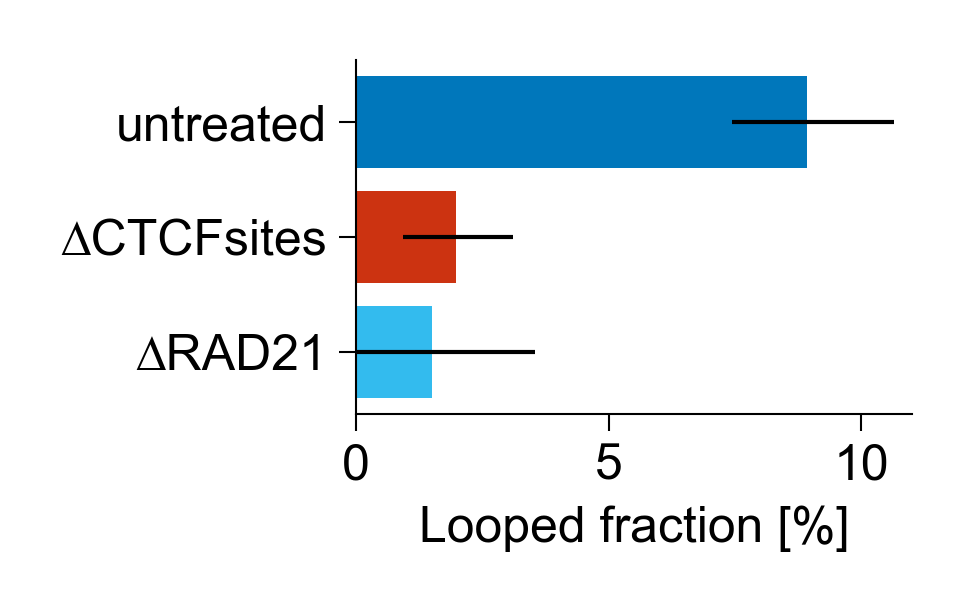

In [10]:
fig, ax = plt.subplots(figsize=(1.6, 1.0), dpi=300, frameon=False)

y = 2
for condition in conditions:
    x = np.mean(corrected_looped_frac_bootstrap_dists[condition])
    x_CI_lower = np.quantile(corrected_looped_frac_bootstrap_dists[condition], 0.025)
    x_CI_upper = np.quantile(corrected_looped_frac_bootstrap_dists[condition], 0.975)
    ax.barh(width=[x], y=[y], color=colors_dict[condition], xerr=[[x-x_CI_lower], [x_CI_upper-x]])
    y = y - 1

ax.set_yticks([2, 1, 0], [names_dict[condition] for condition in conditions])
ax.set_xlabel('Looped fraction [%]')

ax.set_xlim(0, 11);
ax.spines[['top', 'right']].set_visible(False);

plt.tight_layout();
plt.savefig(f'{figures_path}/looped_fraction.svg')


# Panel f: Loop lifetimes

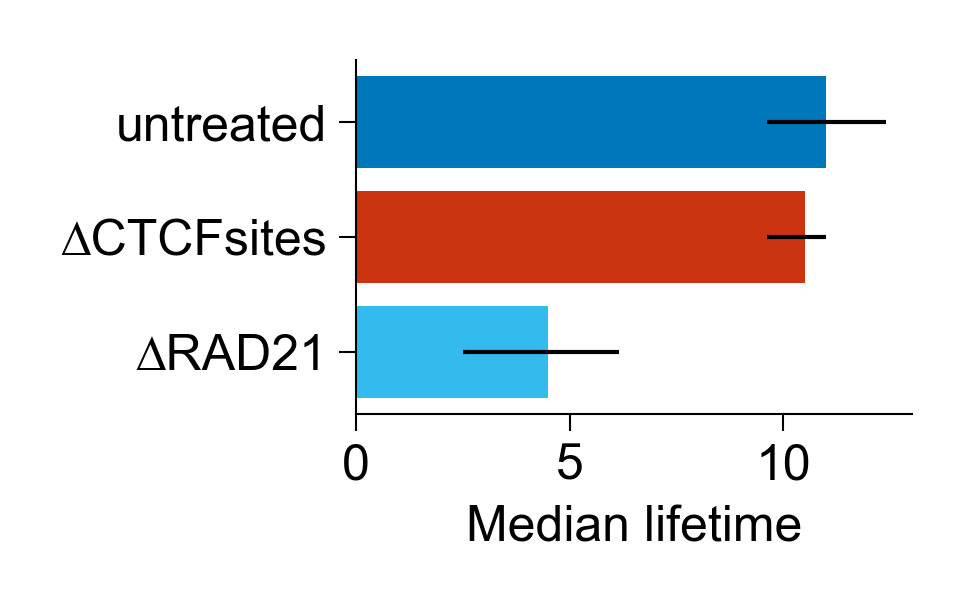

In [11]:
fig, ax = plt.subplots(figsize=(1.6, 1.0), dpi=300, frameon=False)

y = 2
for condition in conditions:
    m, m_ci = loop_lifetimes_medians_and_CIs[condition]
    x = m
    ax.barh(width=[x], y=[y], color=colors_dict[condition], xerr=[[m-m_ci[0]], [m_ci[1]-m]])
    y = y - 1

ax.set_yticks([2, 1, 0], [names_dict[condition] for condition in conditions])
ax.set_xlabel('Median lifetime')

ax.set_xlim(0, 13);
ax.spines[['top', 'right']].set_visible(False);

plt.tight_layout()
plt.savefig(f'{figures_path}/loop_lifetimes.svg')


# Obsolete: Bootstrap distributions of looped fraction

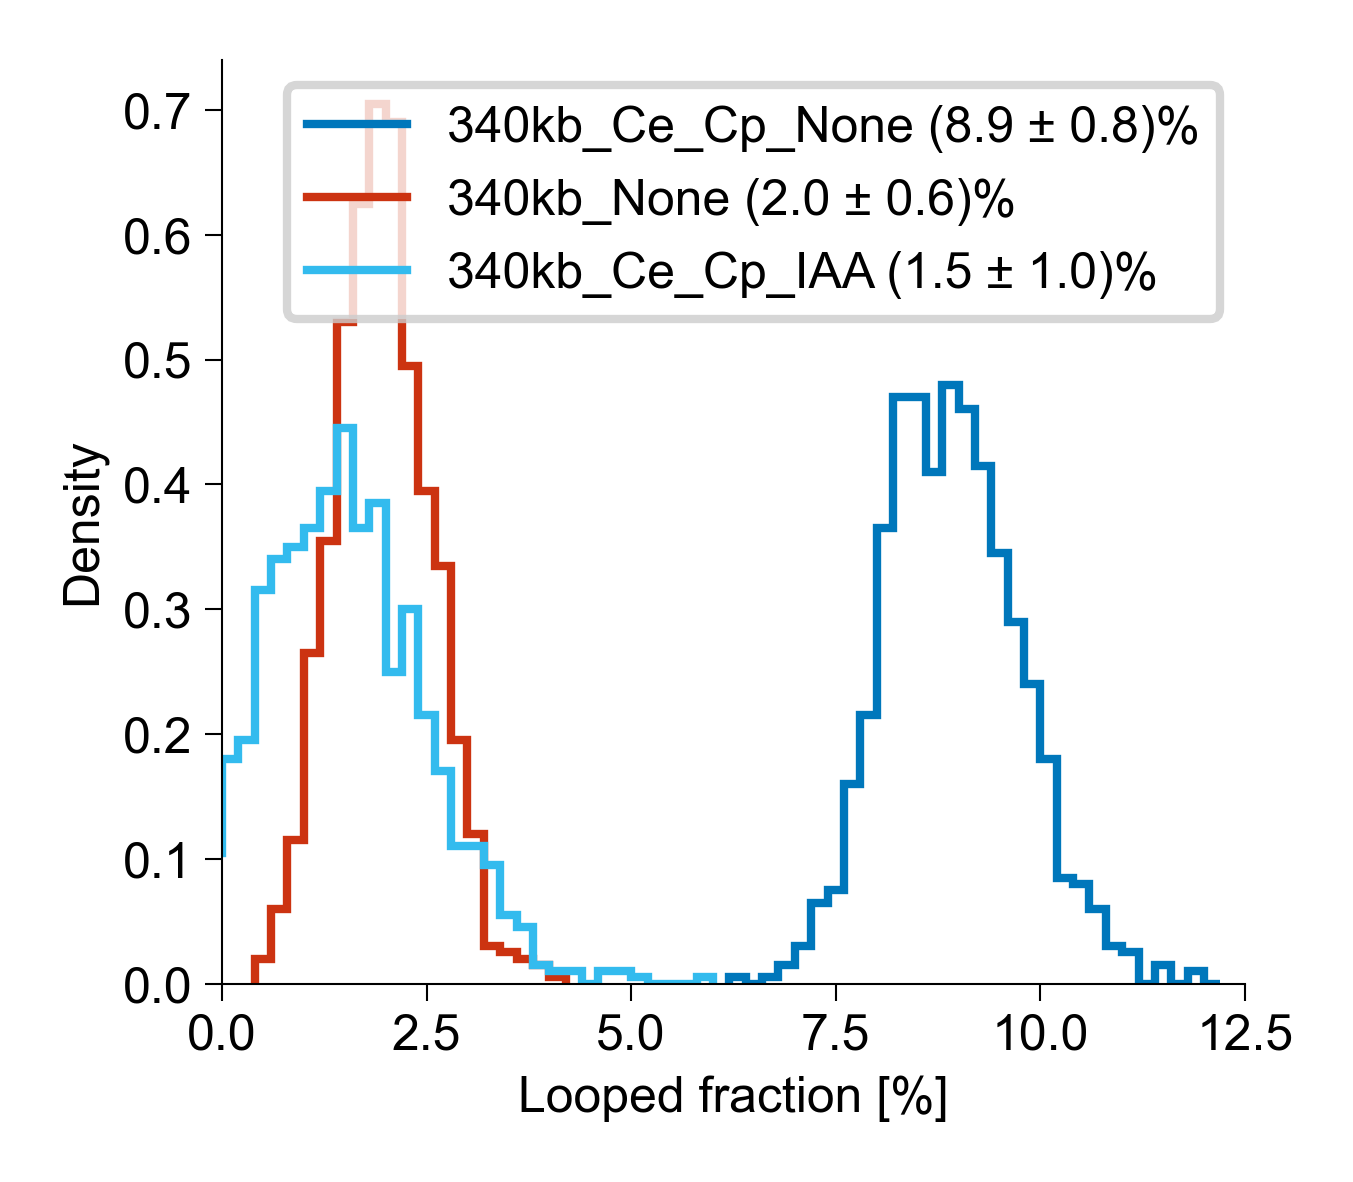

In [12]:
fig, ax = plt.subplots(figsize=(2.2,2.0), dpi=300)
binsize = 0.2

for condition in conditions:
    bootstrap_dist = corrected_looped_frac_bootstrap_dists[condition]

    lower = np.divmod(np.min(bootstrap_dist),binsize)[0]*binsize
    upper = (np.divmod(np.max(bootstrap_dist),binsize)[0]+2)*binsize
    y, x = np.histogram(bootstrap_dist, bins=np.arange(lower, upper, binsize), density=True)
    mean = np.mean(bootstrap_dist)
    std = np.std(bootstrap_dist)
    ax.stairs(y, x, color=colors_dict[condition], label=f'{condition} ({mean:.1f} ± {std:.1f})%');

ax.legend()
ax.set_xlabel('Looped fraction [%]')
ax.set_xlim(0, 12.5);
ax.set_ylabel('Density')
ax.spines[['top', 'right']].set_visible(False)

plt.show();
